In [1]:
from dlfs.layers import EmbeddingLayer, PositionalEncoding, DenseLayer
from dlfs.modules import TransformerDecoder

from dlfs.activation import Softmax, ReLU
from dlfs.loss import CCE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.base import Module, Activation, Loss, Optimizer

import numpy as np

# Transformer Decoder only model (GPT like)

In [2]:
class TransformerDecoderModel(Module):

    def __init__(self, vocab_size: int, seq_len: int, 
                       n_embed: int = 512, n_head: int = 4, n_dec_layers: int = 2, dim_ff: int = 2048, 
                       dropout: float = 0.1, activation: Activation = ReLU(), layer_norm_eps: float = 1e-5, 
                       loss_function: Loss = None, optimizer: Optimizer = None) -> None:
        """
        Decoder only model similar to GPT.

        Parameters
        ----------
        vocab_size : int
            The size of the vocabulary, i.e., the total number of unique tokens (words/characters) in the dataset.

        seq_len : int
            The maximum sequence length of the input/output sequences. The model will be trained on sequences of this length.

        n_embed : int, default=512
            The dimensionality of the embedding vectors for both input and output.

        n_head : int, default=4
            The number of attention heads in each attention layer.

        n_dec_layers : int, default=2
            The number of decoder layers.

        dim_ff : int, default=2048
            The dimensionality of the feedforward layers in the encoder and decoder.

        dropout : float, default=0.1
            The dropout rate applied to layers during training to help prevent overfitting.

        activation : Activation, default=ReLU()
            The activation function used in the feedforward layers.

        layer_norm_eps : float, default=1e-5
            A small value added to the denominator for numerical stability when performing layer normalization.

        loss_function : Loss, default=None
            The loss function used during training.

        optimizer : Optimizer, default=None
            The optimizer used for training.

        Returns
        -------
        None
        """
        
        self.loss_function = loss_function
        self.optimizer = optimizer

        self.embed = EmbeddingLayer(vocab_size, n_embed)
        self.pos_enc = PositionalEncoding(seq_len, n_embed)

        self.decoder = TransformerDecoder(d_model=n_embed, n_head=n_head, n_dec_layers=n_dec_layers,
                                          dim_ff=dim_ff, dropout=dropout, activation=activation, layer_norm_eps=layer_norm_eps)

        self.linear = DenseLayer(n_embed, vocab_size)
        self.softm = Softmax()

    def forward(self, inputs: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the Transformer Decoder model. Creates output attribute (logits) of shape `(batch_size, seq_len, vocab_size)`.

        Parameters
        ----------
        inputs : np.ndarray
            The input sequence for the decoder of shape `(batch_size, seq_len)`.

        training : bool, default=False
            A flag indicating whether the model is in training mode (`True`) or inference mode (`False`).
            This controls dropout, which is only applied during training.

        Returns
        -------
        None

        Notes
        -----
        - `inputs` are expected to be token indices for the decoder sequences.
        - The output is typically passed through a softmax function externally for final predictions (e.g., during inference).
        """

        # Embed decoder input, outputs (batch_size, seq_len, n_embed)
        self.embed.forward(inputs, training)

        # Add positional encoding to embeddings, outputs (batch_size, seq_len, n_embed)
        self.pos_enc.forward(self.embed.output, training)

        # Pass embedded inputs through the Decoder, outputs (batch_size, seq_len, n_embed)
        self.decoder.forward(self.pos_enc.output, training=training)

        # Map Decoder output to raw logits, outputs (batch_size, seq_len, vocab_size)
        self.linear.forward(self.decoder.output, training)

        # Create output attribute to be the final layer's output
        self.output = self.linear.output

    def backward(self, y: np.ndarray) -> None:
        """
        Backward pass for the Transformer Decoder model. Computes gradients for all Decoder modules.

        Parameters
        ----------
        y : np.ndarray
            The true labels (indices) for the model's output of shape `(batch_size, seq_len)`.

        Returns
        -------
        None
        """

        # Reshape y_pred and y_true for CCE
        B, T, C = self.output.shape
        y_pred = self.output.reshape(B*T, C)
        y_true = y.reshape(B*T, )

        # Compute loss gradient
        self.loss_function.backward(y_pred, y_true)
        
        # Backprop through linear
        self.linear.backward(self.loss_function.dinputs.reshape(B, T, C))

        # Backprop through decoder, positional encoding, and embedding
        self.decoder.backward(self.linear.dinputs)
        self.pos_enc.backward(self.decoder.dinputs)
        self.embed.backward(self.pos_enc.dinputs)

    def train(self, X: np.ndarray, y: np.ndarray, epochs = 1000, batch_size: int = None, print_every: int = None) -> None:
        """
        Train the model for a specified number of epochs, updating parameters using backpropagation.

        Parameters
        ----------
        X : np.ndarray
            Decoder input data (shifted targets) of shape `(batch_size, seq_len)`.

        y : np.ndarray
            True target labels (indices) of shape `(batch_size, seq_len)`.

        epochs : int, default=1000
            The number of epochs to train the model.

        batch_size : int, default=None
            The size of the batch to use for each training step. If `None`, the entire dataset is used
            for each forward/backward pass.

        print_every : int, default=None
            If provided, will print the current loss value every 
            `print_every` epochs.

        Returns
        -------
        None
        """

        # Store loss values for plotting
        self.loss_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:
                batch_X, batch_y = get_random_batch(X, y, batch_size)
                batch_X, batch_y = batch_X.astype(int), batch_y.astype(int)
            else:
                # If batch size is not specified take the whole dataset
                batch_X, batch_y = X, y
                batch_X, batch_y = batch_X.astype(int), batch_y.astype(int)

            # Forward pass
            self.forward(batch_X, training=True)

            # Backward pass
            self.backward(batch_y)

            # Update parameters
            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            # Store current loss
            B, T, C = self.output.shape
            loss = self.loss_function.calculate(self.output.reshape(B*T, C), batch_y.reshape(B*T))
            self.loss_vals.append(loss)

            if print_every is not None and not i % print_every:
                print(f'===== EPOCH : {i} ===== LOSS : {loss} =====')
                
    def generate(self, idx: np.ndarray, context_window: int, max_new_tokens: int = 100):
        """
        Generate sequences autoregressively using the trained Transformer Decoder model.

        Parameters
        ----------
        idx : np.ndarray
            The initial input sequence of tokens, shape `(batch_size, seq_len)`. This sequence will be used as the starting context for generation.

        context_window : int
            The length of the context window to consider for each step in the autoregressive generation. 
            Typically, this is the number of previous tokens the model uses to generate the next token.
            
        max_new_tokens : int, default=1000
            The maximum length of the sequence to be generated. Generation will stop either when
            this length is reached or when an end token (`end_token`) is generated.

        Returns
        -------
        np.ndarray
            The generated sequence of tokens for each input in the batch of shape `(batch_size, max_len)`.
        """
            
        for _ in range(max_new_tokens):

            current_context = idx[:, -context_window:]

            self.forward(current_context, training=False)
            self.softm.forward(self.output, training=False)
    
            probs = self.softm.output
            probs = probs[:, -1, :].reshape(-1)

            idx_next = np.argmax(np.random.multinomial(n=1, pvals=probs, size=1), axis=1).reshape(1, 1)

            idx = np.concatenate((idx, idx_next), axis=1)

        return idx

# Dummy dataset, helper functions

In [3]:
def generate_decoder_dataset(num_samples: int, seq_len: int, vocab_size: int, sos_token: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate a dataset for training a GPT-like model with randomly generated sequences.

    Parameters
    ----------
    num_samples : int
        The number of samples (sequences) to generate in the dataset.
    
    seq_len : int
        The length of each sequence.
    
    vocab_size : int
        The size of the vocabulary, the range of values for each token in the sequence (from 1 to `vocab_size`).
    
    sos_token : int, default=0
        The integer value representing the start-of-sequence (SOS) token.
    
    Returns
    -------
    X : np.ndarray
        Array of shape `(num_samples, seq_len)` containing the generated sequences shifted to the right.
        
    y : np.ndarray
        Array of shape `(num_samples, seq_len)` containing the original generated sequences.
    """
    
    # Random sequences
    X_raw = np.random.randint(1, vocab_size+1, size=(num_samples, seq_len))

    # Decoder input: prepend SOS, remove last element
    X = np.zeros_like(X_raw)
    X[:, 1:] = X_raw[:, :-1]
    X[:, 0] = sos_token

    # Target is the original sequence
    y = X_raw.copy()

    return X, y

def get_random_batch(X: np.ndarray, y: np.ndarray, batch_size: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Sample a random batch of data from the dataset.

    Parameters
    ----------
    X : np.ndarray
        Input array of shape `(num_samples, seq_len)`.
        
    y : np.ndarray
        True values array of shape `(num_samples, seq_len)`.
        
    batch_size : int
        The number of samples to include in the batch.

    Returns
    -------
    batch_X : np.ndarray
        Input array containing a random selection of sequences from `X` of shape `(batch_size, seq_len)`.
        
    batch_y : np.ndarray
        True values array containing a random selection of sequences from `y` of shape `(batch_size, seq_len)`.
    """

    idx = np.random.randint(0, len(X), size=(batch_size, ))
    return X[idx], y[idx]

# Create dataset

In [4]:
num_samples = 100
seq_len = 5
vocab_size = 20

X_train, y_train = generate_decoder_dataset(num_samples, seq_len, vocab_size)

print('-----------------------------------------------------')
print(f'Data shapes:\nX: {X_train.shape} || y: {y_train.shape}')
print('-----------------------------------------------------')
print(f'Decoder inputs are targets shifted right by one token.')
print(f'Example input sequence for decoder (shifted right, starts with SOS token): {X_train[0]}')
print(f'Example target sequence: {y_train[0]}')
print('-----------------------------------------------------')

-----------------------------------------------------
Data shapes:
X: (100, 5) || y: (100, 5)
-----------------------------------------------------
Decoder inputs are targets shifted right by one token.
Example input sequence for decoder (shifted right, starts with SOS token): [ 0  9 15  5 17]
Example target sequence: [ 9 15  5 17 16]
-----------------------------------------------------


# Model training

In [5]:
#np.random.seed(1) # setting seed for reproducibility

vocab_size += 1 # increase vocab_size by 1 because of SOS token
batch_size = None

n_embed = 64 # dim of token embeddings
n_head = 8 # number of attention heads, n_embed must divide n_head
n_dec_layers = 1
dim_ff = 128
dropout = 0.
eps = 1e-5

epochs = 2000
lr = 1e-4

loss = CCE_Loss(from_logits=True) # model outputs raw logits
optimizer = Optimizer_Adam(learning_rate=lr, decay=0., clip_grad=False)

model = TransformerDecoderModel(vocab_size=vocab_size, 
                         seq_len=seq_len, 
                         n_embed=n_embed, 
                         n_head=n_head,
                         n_dec_layers=n_dec_layers,
                         dim_ff=dim_ff, 
                         dropout=dropout,
                         layer_norm_eps=eps,
                         loss_function=loss, 
                         optimizer=optimizer)

model.train(X_train, y_train, print_every=400, epochs=epochs, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS : 5.870480831829771 =====
===== EPOCH : 400 ===== LOSS : 2.7170575234964836 =====
===== EPOCH : 800 ===== LOSS : 2.179691216329078 =====
===== EPOCH : 1200 ===== LOSS : 1.6647122914123929 =====
===== EPOCH : 1600 ===== LOSS : 1.345190020025881 =====
===== EPOCH : 2000 ===== LOSS : 1.1525520793037514 =====


# Loss plotting

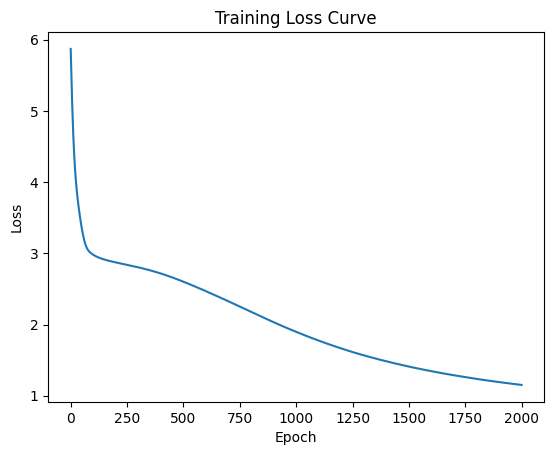

In [6]:
import matplotlib.pyplot as plt

plt.plot(range(len(model.loss_vals)), model.loss_vals)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Autoregressive generation

In [7]:
output = model.generate(idx=np.zeros((1, 1), dtype=np.int32), context_window=seq_len, max_new_tokens=50)
print(output)

[[ 0 13 15 16 11  9 20 17 13  9 18 15  9 20 17  8  6  5 17 11  9 20 17 13
   9  6 19  9  4 19 16  6  2 11  7 14  6 20 19 13 18 16  6  2  3  7 11 10
   1 13 20]]
